Dataset Loaded Successfully
(552, 28)

Feature Shape: (552, 27)
Target Shape: (552,)

Training Shape: (441, 27)
Testing Shape: (111, 27)

Preprocessing Pipeline Ready

Scale Positive Weight: 2.127659574468085

Pipeline Created Successfully


C:\Users\vivek\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Quick Pipeline Test Successful
First 5 Predictions:
[0.00437894 0.97531699 0.34772589 0.53151502 0.27891332]

Starting Hyperparameter Search...

Fitting 10 folds for each of 100 candidates, totalling 1000 fits

Hyperparameter Tuning Complete

Best Parameters:
{'classifier__subsample': 0.8, 'classifier__reg_lambda': 1.5, 'classifier__reg_alpha': 0, 'classifier__num_leaves': 127, 'classifier__n_estimators': 200, 'classifier__min_child_samples': 30, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 1.0}

Best Cross-Validated PR-AUC:
0.5700353047753939

Best Threshold: 0.5102307432749308
Best G-Mean: 0.8486395732556362

========== FINAL MODEL PERFORMANCE ==========
Accuracy      : 0.631
Precision     : 0.442
Recall        : 0.528
Specificity   : 0.680
F1-score      : 0.481
MCC           : 0.200
ROC-AUC       : 0.636
PR-AUC        : 0.456
Brier Score   : 0.226


C:\Users\vivek\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\vivek\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


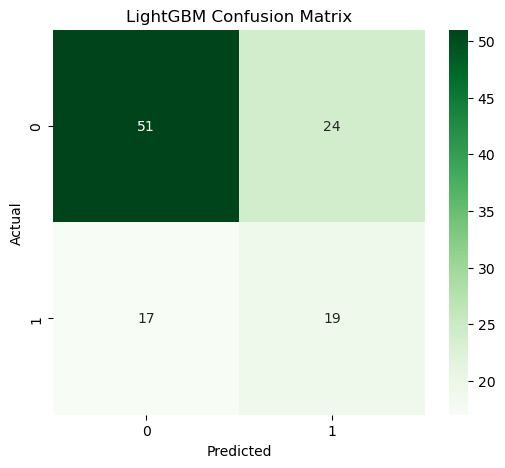


Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.68      0.71        75
           1       0.44      0.53      0.48        36

    accuracy                           0.63       111
   macro avg       0.60      0.60      0.60       111
weighted avg       0.65      0.63      0.64       111



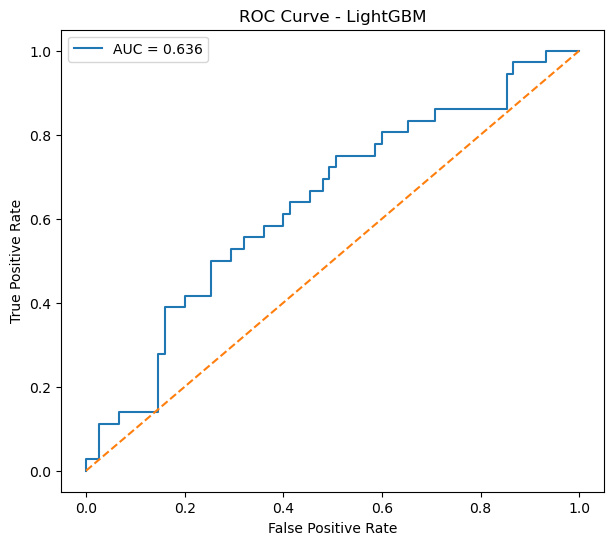

C:\Users\vivek\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\vivek\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\vivek\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\vivek\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\vivek\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\vivek\anaconda3\Lib\site-p


========== 95% CONFIDENCE INTERVALS ==========
ACCURACY: 0.633 (95% CI: 0.541 - 0.721)
PRECISION: 0.442 (95% CI: 0.290 - 0.588)
RECALL: 0.527 (95% CI: 0.359 - 0.694)
SPECIFICITY: 0.683 (95% CI: 0.579 - 0.786)
F1: 0.478 (95% CI: 0.333 - 0.607)
MCC: 0.201 (95% CI: 0.003 - 0.382)
ROC_AUC: 0.638 (95% CI: 0.525 - 0.742)
PR_AUC: 0.471 (95% CI: 0.318 - 0.621)
BRIER: 0.225 (95% CI: 0.191 - 0.263)

Computing SHAP Values...
SHAP Computation Complete


C:\Users\vivek\anaconda3\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


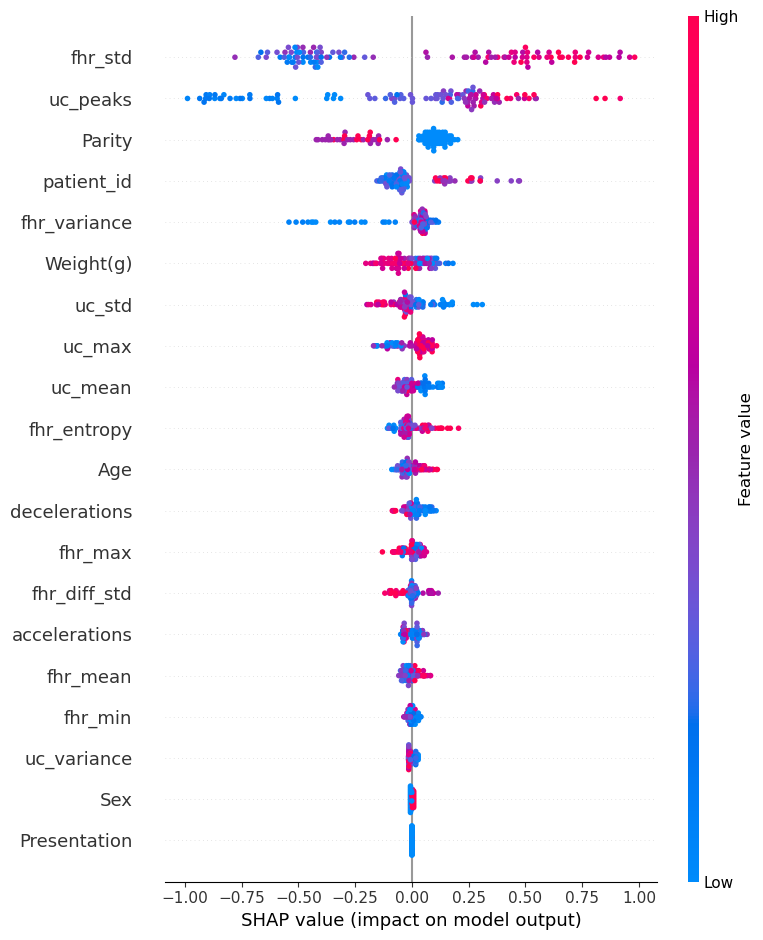

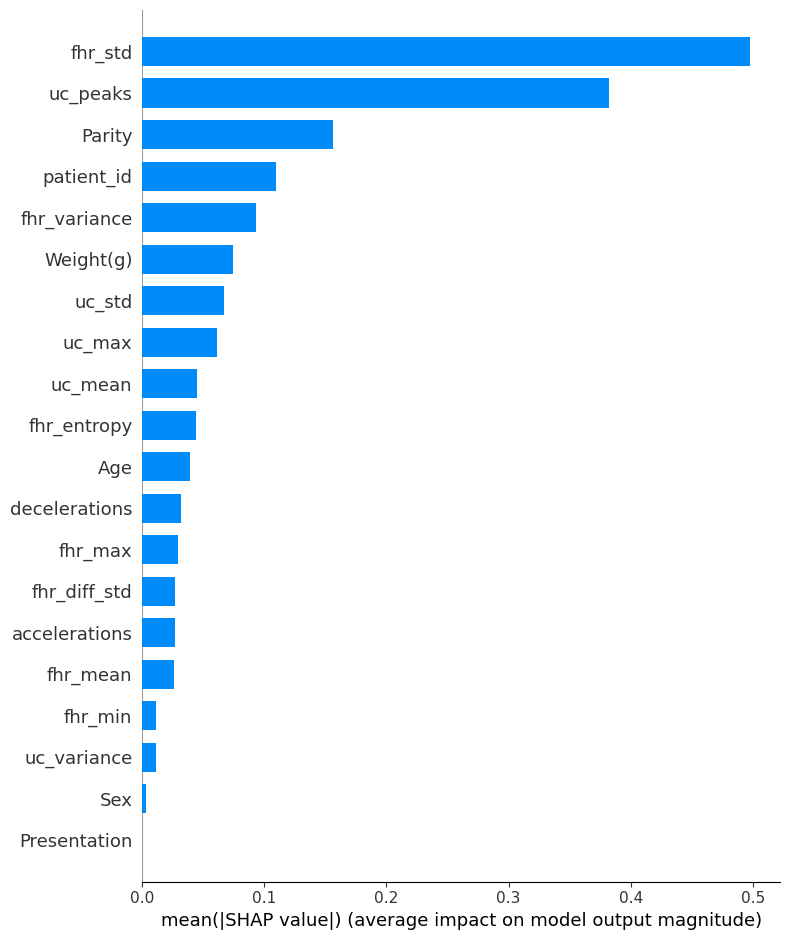

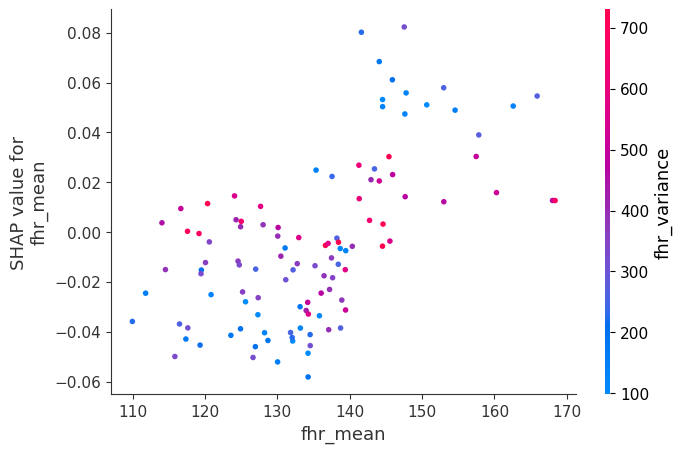

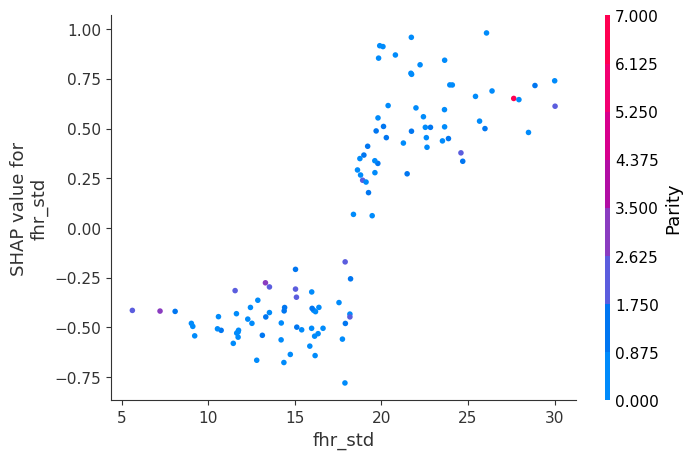

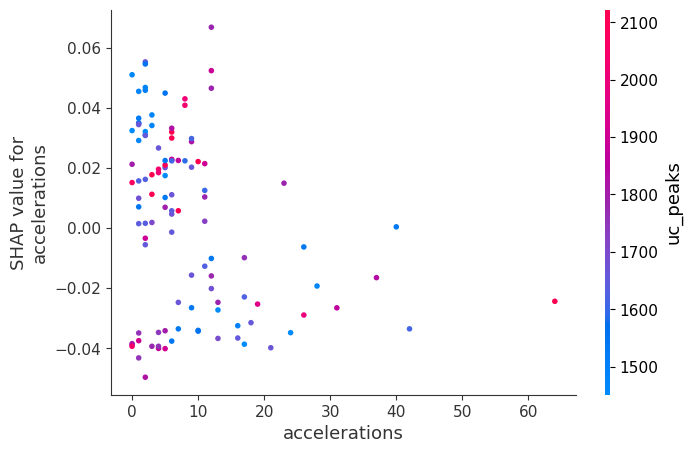


Model Saved Successfully


In [1]:
# ============================================================
# ADVANCED LIGHTGBM PIPELINE
# CTU-CHB MULTIMODAL FETAL RISK PREDICTION
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    brier_score_loss,
    confusion_matrix,
    roc_curve,
    classification_report
)

from sklearn.utils import resample

from lightgbm import LGBMClassifier

import shap


# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv(r"C:\Users\vivek\Desktop\KI_Project\Project 3\fetal_multimodal_dataset.csv")

print("Dataset Loaded Successfully")
print(df.shape)


# ============================================================
# 3. DEFINE FEATURES + TARGET
# ============================================================

TARGET_COLUMN = "target"

X = df.drop(columns=[TARGET_COLUMN])

y = df[TARGET_COLUMN]

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)


# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


# ============================================================
# 5. PREPROCESSING
# ============================================================

numeric_features = X_train.columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ]
)

print("\nPreprocessing Pipeline Ready")


# ============================================================
# 6. CLASS IMBALANCE WEIGHT
# ============================================================

negative_count = y_train.value_counts()[0]

positive_count = y_train.value_counts()[1]

scale_pos_weight = negative_count / positive_count

print("\nScale Positive Weight:", scale_pos_weight)


# ============================================================
# 7. BUILD LIGHTGBM PIPELINE
# ============================================================

pipeline = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('classifier', LGBMClassifier(

        objective='binary',

        random_state=42,

        scale_pos_weight=scale_pos_weight,

        verbosity=-1
    ))
])

print("\nPipeline Created Successfully")


# ============================================================
# 8. QUICK TEST RUN
# ============================================================

pipeline.fit(X_train, y_train)

y_prob = pipeline.predict_proba(X_test)[:, 1]

print("\nQuick Pipeline Test Successful")
print("First 5 Predictions:")
print(y_prob[:5])


# ============================================================
# 9. CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)


# ============================================================
# 10. HYPERPARAMETER SEARCH SPACE
# ============================================================

param_dist = {

    'classifier__n_estimators': [100, 200, 300, 400],

    'classifier__max_depth': [3, 4, 5, 6, 8],

    'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1],

    'classifier__num_leaves': [15, 31, 63, 127],

    'classifier__subsample': [0.7, 0.8, 1.0],

    'classifier__colsample_bytree': [0.7, 0.8, 1.0],

    'classifier__min_child_samples': [5, 10, 20, 30],

    'classifier__reg_alpha': [0, 0.01, 0.1],

    'classifier__reg_lambda': [1, 1.5, 2]
}


# ============================================================
# 11. RANDOMIZED SEARCH
# ============================================================

search = RandomizedSearchCV(

    estimator=pipeline,

    param_distributions=param_dist,

    n_iter=100,

    scoring='average_precision',

    cv=cv,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

print("\nStarting Hyperparameter Search...\n")


# ============================================================
# 12. TRAIN MODEL
# ============================================================

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nHyperparameter Tuning Complete")


# ============================================================
# 13. BEST PARAMETERS
# ============================================================

print("\nBest Parameters:")
print(search.best_params_)

print("\nBest Cross-Validated PR-AUC:")
print(search.best_score_)


# ============================================================
# 14. G-MEAN THRESHOLD OPTIMIZATION
# ============================================================

y_train_prob = best_model.predict_proba(X_train)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_train,
    y_train_prob
)

gmeans = np.sqrt(tpr * (1 - fpr))

ix = np.argmax(gmeans)

best_threshold = thresholds[ix]

print("\nBest Threshold:", best_threshold)

print("Best G-Mean:", gmeans[ix])


# ============================================================
# 15. TEST SET EVALUATION
# ============================================================

y_test_prob = best_model.predict_proba(X_test)[:, 1]

y_test_pred = (
    y_test_prob >= best_threshold
).astype(int)


# ============================================================
# 16. METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_test_pred
)

precision = precision_score(
    y_test,
    y_test_pred
)

recall = recall_score(
    y_test,
    y_test_pred
)

f1 = f1_score(
    y_test,
    y_test_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_test_prob
)

pr_auc = average_precision_score(
    y_test,
    y_test_prob
)

mcc = matthews_corrcoef(
    y_test,
    y_test_pred
)

brier = brier_score_loss(
    y_test,
    y_test_prob
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred
).ravel()

specificity = tn / (tn + fp)


# ============================================================
# 17. PRINT FINAL RESULTS
# ============================================================

print("\n========== FINAL MODEL PERFORMANCE ==========")

print(f"Accuracy      : {accuracy:.3f}")

print(f"Precision     : {precision:.3f}")

print(f"Recall        : {recall:.3f}")

print(f"Specificity   : {specificity:.3f}")

print(f"F1-score      : {f1:.3f}")

print(f"MCC           : {mcc:.3f}")

print(f"ROC-AUC       : {roc_auc:.3f}")

print(f"PR-AUC        : {pr_auc:.3f}")

print(f"Brier Score   : {brier:.3f}")


# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("LightGBM Confusion Matrix")

plt.show()


# ============================================================
# 19. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_test_pred
))


# ============================================================
# 20. ROC CURVE
# ============================================================

fpr_test, tpr_test, _ = roc_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr_test,
    tpr_test,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - LightGBM")

plt.legend()

plt.show()


# ============================================================
# 21. BOOTSTRAP CONFIDENCE INTERVALS
# ============================================================

n_iterations = 1000

metrics_bootstrap = {

    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "mcc": [],
    "roc_auc": [],
    "pr_auc": [],
    "brier": []
}

for _ in range(n_iterations):

    X_res, y_res = resample(
        X_test,
        y_test,
        replace=True
    )

    y_prob = best_model.predict_proba(X_res)[:, 1]

    y_pred = (
        y_prob >= best_threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_res,
        y_pred
    ).ravel()

    specificity = tn / (tn + fp)

    metrics_bootstrap["accuracy"].append(
        accuracy_score(y_res, y_pred)
    )

    metrics_bootstrap["precision"].append(
        precision_score(y_res, y_pred)
    )

    metrics_bootstrap["recall"].append(
        recall_score(y_res, y_pred)
    )

    metrics_bootstrap["specificity"].append(
        specificity
    )

    metrics_bootstrap["f1"].append(
        f1_score(y_res, y_pred)
    )

    metrics_bootstrap["mcc"].append(
        matthews_corrcoef(y_res, y_pred)
    )

    metrics_bootstrap["roc_auc"].append(
        roc_auc_score(y_res, y_prob)
    )

    metrics_bootstrap["pr_auc"].append(
        average_precision_score(y_res, y_prob)
    )

    metrics_bootstrap["brier"].append(
        brier_score_loss(y_res, y_prob)
    )


# ============================================================
# 22. CONFIDENCE INTERVAL FUNCTION
# ============================================================

def compute_ci(values):

    lower = np.percentile(values, 2.5)

    upper = np.percentile(values, 97.5)

    mean = np.mean(values)

    return mean, lower, upper


print("\n========== 95% CONFIDENCE INTERVALS ==========")

for metric, values in metrics_bootstrap.items():

    mean, lower, upper = compute_ci(values)

    print(
        f"{metric.upper()}: "
        f"{mean:.3f} "
        f"(95% CI: {lower:.3f} - {upper:.3f})"
    )


# ============================================================
# 23. SHAP INTERPRETABILITY
# ============================================================

print("\nComputing SHAP Values...")

model = best_model.named_steps['classifier']

preprocessor = best_model.named_steps['preprocessor']

X_test_transformed = preprocessor.transform(X_test)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(
    X_test_transformed
)

print("SHAP Computation Complete")


# ============================================================
# 24. SHAP SUMMARY PLOT
# ============================================================

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns
)


# ============================================================
# 25. SHAP BAR PLOT
# ============================================================

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)


# ============================================================
# 26. OPTIONAL DEPENDENCE PLOTS
# ============================================================

TOP_FEATURES = [
    "fhr_mean",
    "fhr_std",
    "accelerations"
]

for feature in TOP_FEATURES:

    if feature in X_test.columns:

        shap.dependence_plot(
            feature,
            shap_values,
            X_test
        )


# ============================================================
# 27. SAVE MODEL
# ============================================================

import joblib

joblib.dump(
    best_model,
    "best_lightgbm_ctg_model.pkl"
)

print("\nModel Saved Successfully")